In [274]:
import os
import math
import cv2
import numpy as np
import pandas as pd
from scipy import interpolate, signal
from pathlib import Path
from PIL import Image
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')
from scan import scan_file
from mutiple_group_test import my_oneWayAnova
from matplotlib import pyplot as plt
%matplotlib inline

In [374]:
from matplotlib.pyplot import MultipleLocator
from scipy.stats import kruskal

###分别对ring_cross和ring_length做统计检验
def graph_diagram(df,para,type):
    # para=df.columns.values[:-1]
    # print(para)

    all_p=[]
    ##调用one-way-anova
    for i,parameters in enumerate(para):
        print(f'参数{parameters}统计学差异：')
        diff1,diff2=my_oneWayAnova(df,cata_name='region',num_name=parameters)
        round_p=np.array([[parameters]*3,diff2['group1'],diff2['group2'],diff2['p-adj']]).T  ##['group1'],diff2['group2'],diff2['p-adj']]
        all_p.append(round_p)

    p_cross=np.array(all_p).reshape(-1,4)[:,:].tolist()
    ##根据p值确定显著性
    for i in p_cross:

        if float(i[3])<0.05:
            i.append('Y')
        else:
            i.append('N')
    ##显著性保存为csv文件
    pd.DataFrame(p_cross,columns=['group','region1','region2','p','sig']).to_csv(path+'\\'+f'{type}_sig.csv')

C:\ProgramData\Anaconda3\envs\pythonProject1\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
C:\ProgramData\Anaconda3\envs\pythonProject1\lib\site-packages\numpy\core\fromnumeric.py:3571: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
C:\ProgramData\Anaconda3\envs\pythonProject1\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: The default value of nume

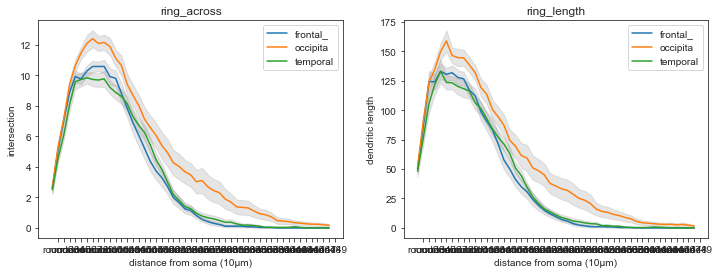

In [454]:
path=r'F:\jcy\humen_brain\electrophysiology\reconstruction\homer_reconstructed\img_procession'

ring_across=pd.read_csv(path+'\\homer_ring_across.csv')
cell_name=ring_across['Filename'].values
ring_across=ring_across.drop('Filename',axis='columns')
ring_across_gro=ring_across.groupby(ring_across['region'])
para=[i for i in ring_across.columns.values if i.startswith('round')]

plt.figure(figsize=(12,4))
###三组数据整体进行KW检验
p_cross=kruskal(*[np.mean(group,axis=0) for name,group in ring_across_gro])
if p_cross.pvalue>0.05:
    print('ring cross----The main effect was not significant')

###依次绘制同心圆交叉点个数
for name, group in ring_across_gro:
    cross_mean=np.mean(group,axis=0)
    cross_sem=np.std(group,axis=0)/math.sqrt(len(group))

    plt.subplot(121);plt.plot(cross_mean,label=name)
    plt.subplot(121);plt.fill_between(range(len(cross_mean)),cross_mean- cross_sem, cross_mean + cross_sem, color='gray', alpha=0.2)
    plt.legend()
plt.subplot(121);plt.ylabel('intersection');plt.xlabel('distance from soma (10μm)');plt.xticks(np.arange(1,50,1));plt.title('ring_across')

###依次绘制同心圆环内长度
ring_length=pd.read_csv(path+'\\homer_ring_length.csv')
ring_length=ring_length.drop('Filename',axis='columns')
ring_length_gro=ring_length.groupby(ring_length['region'])
###三组数据整体进行KW检验
p_length=kruskal(*[np.mean(group,axis=0) for name,group in ring_length_gro])
if p_length.pvalue>0.05:
    print('ring length----The main effect was not significant')

for name, group in ring_length_gro:
    length_mean=np.mean(group,axis=0)
    length_sem=np.std(group,axis=0)/math.sqrt(len(group))

    plt.subplot(122);plt.plot(length_mean,label=name)
    plt.subplot(122);plt.fill_between(range(len(length_mean)),length_mean- length_sem, length_mean + length_sem, color='gray', alpha=0.2)
    plt.legend()
plt.subplot(122);plt.ylabel('dendritic length');plt.xlabel('distance from soma (10μm)');plt.xticks(np.arange(1,50,1));plt.title('ring_length')
plt.savefig(path+'\\dendrites_density_updata.pdf')
plt.show()

In [457]:
print(para)
graph_diagram(ring_across,para,'homer')

['round1', 'round2', 'round3', 'round4', 'round5', 'round6', 'round7', 'round8', 'round9', 'round10', 'round11', 'round12', 'round13', 'round14', 'round15', 'round16', 'round17', 'round18', 'round19', 'round20', 'round21', 'round22', 'round23', 'round24', 'round25', 'round26', 'round27', 'round28', 'round29', 'round30', 'round31', 'round32', 'round33', 'round34', 'round35', 'round36', 'round37', 'round38', 'round39', 'round40', 'round41', 'round42', 'round43', 'round44', 'round45', 'round46', 'round47', 'round48', 'round49']
参数round1统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round2统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round3统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round4统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round5统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round

In [458]:
graph_diagram(ring_length,para,'homer')

参数round1统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round2统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round3统计学差异：
NO significant difference between the groups
temporal <= occipita <= frontal_
参数round4统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数round5统计学差异：
NO significant difference between the groups
frontal_ <= temporal <= occipita
参数round6统计学差异：
Significant difference between the groups
temporal <= frontal_ < occipita
参数round7统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round8统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round9统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round10统计学差异：
Significant difference between the groups
temporal <= frontal_ < occipita
参数round11统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occi

In [430]:
###计算每个环内所有dendrite的密度
arr=np.ones((len(ring_length),len(para)))

# arr[:,0]=ring_length['region']

for i in range(len(para)):
    a=ring_across.iloc[:,:i]
    ##计算每个round内dendritic density
    round_density=a.apply(lambda x: np.sum(x)/((i+1)*10)**2*(math.pi), axis=1).values
    arr[:,i]=round_density
###将新生成的数据转换为label的dataFrame
length_density=pd.DataFrame(arr,columns=para[:])
length_density['region']=ring_length['region']


In [375]:
graph_diagram(length_density,para[:],'interneurons')

参数round1统计学差异：
Significant difference between the groups

NaN result encountered.

NaN result encountered.

NaN result encountered.

NaN result encountered.
frontal_ <= occipita <= temporal
参数round2统计学差异：
NO significant difference between the groups


C:\Users\nVoke\AppData\Roaming\Python\Python38\site-packages\statsmodels\sandbox\stats\multicomp.py:1292: RuntimeWarning: invalid value encountered in divide
  st_range = np.abs(meandiffs) / std_pairs #studentized range statistic


frontal_ <= temporal <= occipita
参数round3统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round4统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round5统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round6统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round7统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round8统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round9统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round10统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round11统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round12统计学差异：
Significant difference between the groups
temporal <= frontal_ <= occipita
参数round13统计学差异：
Significant difference between the groups
tempor

In [450]:
###计算dendrite饱和环距离胞体远近
ring_across.index=ring_across['region']
saturate_ring=[]

for i in ring_across.values.tolist():
    # print(i)
    ring_ind=np.where(np.array(i[:-1])!=0)
    # print(ring_ind)
    sat_ring_num=(ring_ind[0][-1]+1)*10
    saturate_ring.append(sat_ring_num)
# print(saturate_ring)
pd.DataFrame(zip(cell_name,saturate_ring),columns=['cell_name','saturate_ring']).to_excel(path+'\\'+'saturate_ring.xlsx')
print('finish!')

finish!


Index(['Height', 'Width', 'soma_surface_area', 'axon_total_length',
       'dentrite_exiting_soma', 'dentrite_total_length',
       'dentrite_mean_length', 'dentrite_node_number',
       'dentrite_ending_number', 'dendritic_field_area', 'pixel_size',
       'pixel_len', 'Filename', 'region', 'Soma_w', 'Soma_h', 'ring_cross',
       'ring_length', 'zoom_ratio'],
      dtype='object')
参数soma_surface_area统计学差异：
NO significant difference between the groups
frontal_ <= temporal <= occipita
参数axon_total_length统计学差异：
Significant difference between the groups
frontal_ <= temporal <= occipita
参数dentrite_exiting_soma统计学差异：
NO significant difference between the groups
temporal <= frontal_ <= occipita
参数dentrite_total_length统计学差异：
NO significant difference between the groups
frontal_ <= occipita <= temporal
参数dentrite_mean_length统计学差异：
NO significant difference between the groups
occipita <= frontal_ <= temporal
参数dentrite_node_number统计学差异：
NO significant difference between the groups
temporal <= 

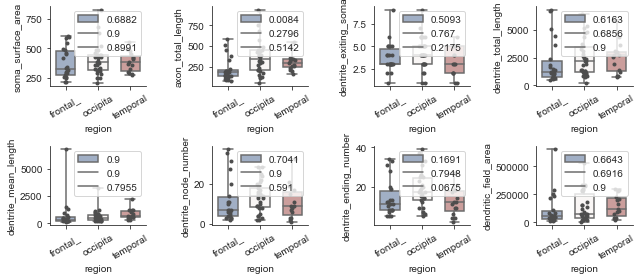

In [396]:
import seaborn as sns
import matplotlib.pyplot as plt
'''
membrane_properties
'''
root_dir=r'F:\jcy\humen_brain\electrophysiology\reconstruction\biotin_reconstructed\all\img_procession'
morphology_features=pd.read_csv(root_dir+'\\biotin_features.csv')
morphology_features.fillna(method = 'pad', axis =0, inplace=True, limit=None)
para=['soma_surface_area', 'axon_total_length','dentrite_exiting_soma', 'dentrite_total_length',
       'dentrite_mean_length', 'dentrite_node_number','dentrite_ending_number', 'dendritic_field_area',]

print(morphology_features.columns)
f, ax = plt.subplots(nrows=2, ncols=4,figsize=(9, 4))
sns.set_style(style="ticks")
for i,parameters in enumerate(para):
    print(f'参数{parameters}统计学差异：')
    diff1,diff2=my_oneWayAnova(morphology_features,cata_name='region',num_name=parameters)
    plt.subplot(2,4,i+1)
    # Plot the orbital period with horizontal boxes
    sns.boxplot(x="region", y=parameters, data=morphology_features,whis=[0, 100], width=.6, palette="vlag")
    plt.legend(diff2['p-adj'],loc=1)
    # Add in points to show each observation
    sns.stripplot(x="region", y=parameters, data=morphology_features,size=4, color=".3", linewidth=0)
    sns.despine()
    plt.xticks(rotation=30)

f.tight_layout()
plt.savefig(root_dir+'\\properties_morphology.pdf')